In [2]:

import pandas as pd

# 1. Carica il dataset
df = pd.read_csv('data/flight_data_2024_sample.csv')

# 2. Definisci il dizionario di traduzione
traduzione_colonne = {
    'year': 'anno',
    'month': 'mese',
    'day_of_month': 'giorno_mese',
    'day_of_week': 'giorno_settimana',
    'fl_date': 'data_volo',
    'op_unique_carrier': 'compagnia_aerea',
    'op_carrier_fl_num': 'numero_volo',
    'origin': 'aeroporto_partenza',
    'origin_city_name': 'citta_partenza',
    'origin_state_nm': 'stato_partenza',
    'dest': 'aeroporto_arrivo',
    'dest_city_name': 'citta_arrivo',
    'dest_state_nm': 'stato_arrivo',
    'crs_dep_time': 'orario_partenza_programmato',
    'dep_time': 'orario_partenza_effettivo',
    'dep_delay': 'ritardo_partenza',
    'taxi_out': 'tempo_rullaggio_partenza',
    'wheels_off': 'orario_decollo',
    'wheels_on': 'orario_atterraggio',
    'taxi_in': 'tempo_rullaggio_arrivo',
    'crs_arr_time': 'orario_arrivo_programmato',
    'arr_time': 'orario_arrivo_effettivo',
    'arr_delay': 'ritardo_arrivo',
    'cancelled': 'cancellato',
    'cancellation_code': 'codice_cancellazione',
    'diverted': 'dirottato',
    'crs_elapsed_time': 'tempo_volo_programmato',
    'actual_elapsed_time': 'tempo_volo_effettivo',
    'air_time': 'tempo_in_aria',
    'distance': 'distanza_miglia',
    'carrier_delay': 'ritardo_compagnia',
    'weather_delay': 'ritardo_meteo',
    'nas_delay': 'ritardo_traffico',
    'security_delay': 'ritardo_sicurezza',
    'late_aircraft_delay': 'ritardo_aereo_precedente'
}

# 3. Applica la rinominazione al DataFrame
# inplace=True significa che modifica direttamente il DataFrame originale 'df'
df.rename(columns=traduzione_colonne, inplace=True)

# 4. Stampiamo le prime righe per verificare!
print(df.columns.tolist())
print("\nPrime 3 righe del dataset :")
print(df.head(3))

['anno', 'mese', 'giorno_mese', 'giorno_settimana', 'data_volo', 'compagnia_aerea', 'numero_volo', 'aeroporto_partenza', 'citta_partenza', 'stato_partenza', 'aeroporto_arrivo', 'citta_arrivo', 'stato_arrivo', 'orario_partenza_programmato', 'orario_partenza_effettivo', 'ritardo_partenza', 'tempo_rullaggio_partenza', 'orario_decollo', 'orario_atterraggio', 'tempo_rullaggio_arrivo', 'orario_arrivo_programmato', 'orario_arrivo_effettivo', 'ritardo_arrivo', 'cancellato', 'codice_cancellazione', 'dirottato', 'tempo_volo_programmato', 'tempo_volo_effettivo', 'tempo_in_aria', 'distanza_miglia', 'ritardo_compagnia', 'ritardo_meteo', 'ritardo_traffico', 'ritardo_sicurezza', 'ritardo_aereo_precedente']

Prime 3 righe del dataset :
   anno  mese  giorno_mese  giorno_settimana   data_volo compagnia_aerea  \
0  2024     4           18                 4  2024-04-18              MQ   
1  2024     1            1                 1  2024-01-01              AA   
2  2024    12           12                

--- INIZIO ANALISI DATI MANCANTI ---

Tabella dei dati mancanti:
                           Dati Mancanti  Percentuale (%)
codice_cancellazione                9878            98.78
tempo_in_aria                        164             1.64
ritardo_arrivo                       164             1.64
tempo_volo_effettivo                 164             1.64
tempo_rullaggio_arrivo               127             1.27
orario_atterraggio                   127             1.27
orario_arrivo_effettivo              127             1.27
tempo_rullaggio_partenza             120             1.20
orario_decollo                       120             1.20
ritardo_partenza                     116             1.16
orario_partenza_effettivo            116             1.16


C:\Users\berry\AppData\Local\Temp\ipykernel_8048\751987241.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=valori_nulli.values, y=valori_nulli.index, palette='Reds_r')


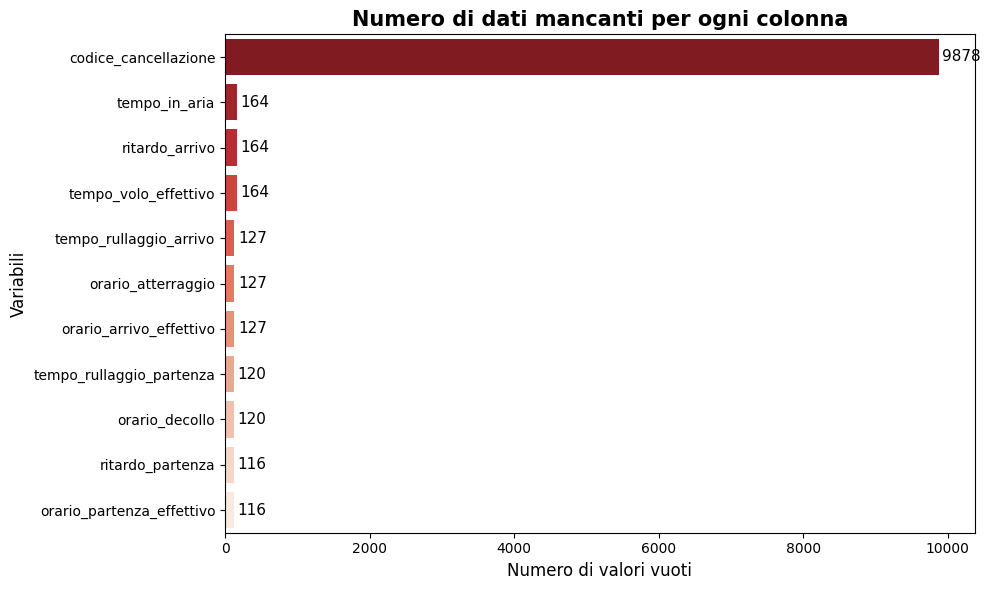


--- CAUSA DEI DATI MANCANTI IN 'ritardo_arrivo' ---
Totale voli senza il dato 'ritardo_arrivo': 164
- Di cui Cancellati: 122
- Di cui Dirottati: 42

-> CONCLUSIONE: Perfetto! Tutti i dati mancanti sul ritardo sono dovuti a voli cancellati o dirottati.


In [3]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix



print("--- INIZIO ANALISI DATI MANCANTI ---")

# 2. Quanti dati mancano?
# Contiamo i nulli per ogni colonna e li mostriamo in ordine decrescente
valori_nulli = df.isnull().sum()
valori_nulli = valori_nulli[valori_nulli > 0].sort_values(ascending=False)
percentuale_nulli = (valori_nulli / len(df)) * 100

tabella_mancanti = pd.DataFrame({
    'Dati Mancanti': valori_nulli, 
    'Percentuale (%)': percentuale_nulli.round(2)
})
print("\nTabella dei dati mancanti:")
print(tabella_mancanti)

# 3. Visualizzazione Grafica (Heatmap)
plt.figure(figsize=(10, 6))



# Disegno grafico ()
# Usiamo sns.barplot per creare barre orizzontali. 
# Sull'asse X mettiamo la quantità di dati mancanti, sull'asse Y i nomi delle colonne
sns.barplot(x=valori_nulli.values, y=valori_nulli.index, palette='Reds_r')

plt.title('Numero di dati mancanti per ogni colonna', fontsize=15, fontweight='bold')
plt.xlabel('Numero di valori vuoti', fontsize=12)
plt.ylabel('Variabili', fontsize=12)

# Questo piccolo ciclo 'for' aggiunge il numerino esatto alla fine di ogni barra!
for index, value in enumerate(valori_nulli.values):
    plt.text(value + 50, index, str(value), va='center', fontsize=11)

plt.tight_layout()
plt.show()

# 4. Conferma dell'ipotesi: I dati mancanti dipendono dalle cancellazioni?
voli_senza_ritardo_arrivo = df[df['ritardo_arrivo'].isnull()]

print("\n--- CAUSA DEI DATI MANCANTI IN 'ritardo_arrivo' ---")
print(f"Totale voli senza il dato 'ritardo_arrivo': {len(voli_senza_ritardo_arrivo)}")
print(f"- Di cui Cancellati: {voli_senza_ritardo_arrivo['cancellato'].sum()}")
print(f"- Di cui Dirottati: {voli_senza_ritardo_arrivo['dirottato'].sum()}")

somma_canc_dir = voli_senza_ritardo_arrivo['cancellato'].sum() + voli_senza_ritardo_arrivo['dirottato'].sum()
if somma_canc_dir == len(voli_senza_ritardo_arrivo):
    print("\n-> CONCLUSIONE: Perfetto! Tutti i dati mancanti sul ritardo sono dovuti a voli cancellati o dirottati.")
else:
    print("\n-> CONCLUSIONE: Attenzione, ci sono altre cause sconosciute per i dati mancanti.")

In [33]:
# Eliminiamo la colonna 'numero_volo'
# axis=1 indica che stiamo eliminando una colonna (non una riga)
# inplace=True applica la modifica direttamente al nostro dataset 'df'
df.drop('numero_volo', axis=1, inplace=True)

# Verifichiamo che non ci sia più stampando la lista delle colonne attuali
print("Colonna 'numero_volo' eliminata!")
print("\nColonne rimanenti nel dataset:")
print(df.columns.tolist())

Colonna 'numero_volo' eliminata!

Colonne rimanenti nel dataset:
['anno', 'mese', 'giorno_mese', 'giorno_settimana', 'data_volo', 'compagnia_aerea', 'aeroporto_partenza', 'citta_partenza', 'stato_partenza', 'aeroporto_arrivo', 'citta_arrivo', 'stato_arrivo', 'orario_partenza_programmato', 'orario_partenza_effettivo', 'ritardo_partenza', 'tempo_rullaggio_partenza', 'orario_decollo', 'orario_atterraggio', 'tempo_rullaggio_arrivo', 'orario_arrivo_programmato', 'orario_arrivo_effettivo', 'ritardo_arrivo', 'cancellato', 'codice_cancellazione', 'dirottato', 'tempo_volo_programmato', 'tempo_volo_effettivo', 'tempo_in_aria', 'distanza_miglia', 'ritardo_compagnia', 'ritardo_meteo', 'ritardo_traffico', 'ritardo_sicurezza', 'ritardo_aereo_precedente']


In [4]:
# Creiamo una copia del dataset per lavorare in sicurezza
df_clean = df.copy()

print("--- INIZIO PULIZIA DEL DATASET ---")

# 1. Filtriamo solo i voli che hanno effettivamente volato
# Teniamo le righe dove 'cancellato' è 0 E 'dirottato' è 0
df_clean = df_clean[(df_clean['cancellato'] == 0) & (df_clean['dirottato'] == 0)]

# 2. Creazione del nostro "Target" (La variabile da prevedere)
# Se il ritardo all'arrivo è maggiore di 15 minuti, vale 1 (Ritardo), altrimenti 0 (In orario)
df_clean['in_ritardo'] = (df_clean['ritardo_arrivo'] > 15).astype(int)

# 3. Eliminiamo le colonne "del futuro" e quelle che non ci servono più
colonne_da_eliminare = [
    'cancellato', 'codice_cancellazione', 'dirottato', # Già usate per filtrare
    'tempo_rullaggio_partenza',    # Non si sanno prima di partire
    'tempo_rullaggio_arrivo',    # Non si sanno prima di arrivare
    
]

# Rimuoviamo la lista di colonne dal dataset
df_clean.drop(columns=colonne_da_eliminare, inplace=True)

# 4. Rimuoviamo eventuali righe rimaste con valori nulli (per sicurezza)
df_clean.dropna(inplace=True)

# --- RISULTATI DELLA PULIZIA ---
print(f"Dimensioni dataset PRIMA della pulizia: {df.shape}")
print(f"Dimensioni dataset PULITO: {df_clean.shape}")

print("\nDistribuzione del nostro Target (0 = In Orario, 1 = In Ritardo):")
print(df_clean['in_ritardo'].value_counts())

print("\nPrime 3 righe del dataset pulito, pronto per l'analisi e i modelli:")
print(df_clean.head(3))


--- INIZIO PULIZIA DEL DATASET ---
Dimensioni dataset PRIMA della pulizia: (10000, 35)
Dimensioni dataset PULITO: (9836, 31)

Distribuzione del nostro Target (0 = In Orario, 1 = In Ritardo):
in_ritardo
0    7796
1    2040
Name: count, dtype: int64

Prime 3 righe del dataset pulito, pronto per l'analisi e i modelli:
   anno  mese  giorno_mese  giorno_settimana   data_volo compagnia_aerea  \
0  2024     4           18                 4  2024-04-18              MQ   
1  2024     1            1                 1  2024-01-01              AA   
2  2024    12           12                 4  2024-12-12              9E   

   numero_volo aeroporto_partenza         citta_partenza  stato_partenza  ...  \
0       3535.0                DFW  Dallas/Fort Worth, TX           Texas  ...   
1        148.0                CLT          Charlotte, NC  North Carolina  ...   
2       5440.0                CHA        Chattanooga, TN       Tennessee  ...   

  tempo_volo_programmato tempo_volo_effettivo tempo_i

In [10]:
# Lista delle variabili predittive (Features) corrette
features_selezionate = [
    'mese', 
    'giorno_mese', 
    'giorno_settimana', 
    'compagnia_aerea', 
    'aeroporto_partenza', 
    'aeroporto_arrivo', 
    'orario_partenza_programmato', 
    'distanza_miglia'
]

# Creiamo X (dati in ingresso) e y (target)
X = df_clean[features_selezionate]
y = df_clean['in_ritardo'] # Il tuo target creato precedentemente

In [11]:
# 2. Trasformiamo le scritte in numeri (0 e 1)
X = pd.get_dummies(X, columns=['compagnia_aerea', 'aeroporto_partenza', 'aeroporto_arrivo'])

C:\Users\berry\AppData\Local\Temp\ipykernel_8048\1086178538.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='mese', y='in_ritardo', errorbar=None, palette='magma')
C:\Users\berry\AppData\Local\Temp\ipykernel_8048\1086178538.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='giorno_settimana', y='in_ritardo', errorbar=None, palette='coolwarm')
C:\Users\berry\AppData\Local\Temp\ipykernel_8048\1086178538.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='compagnia_aerea', y='in_ritard

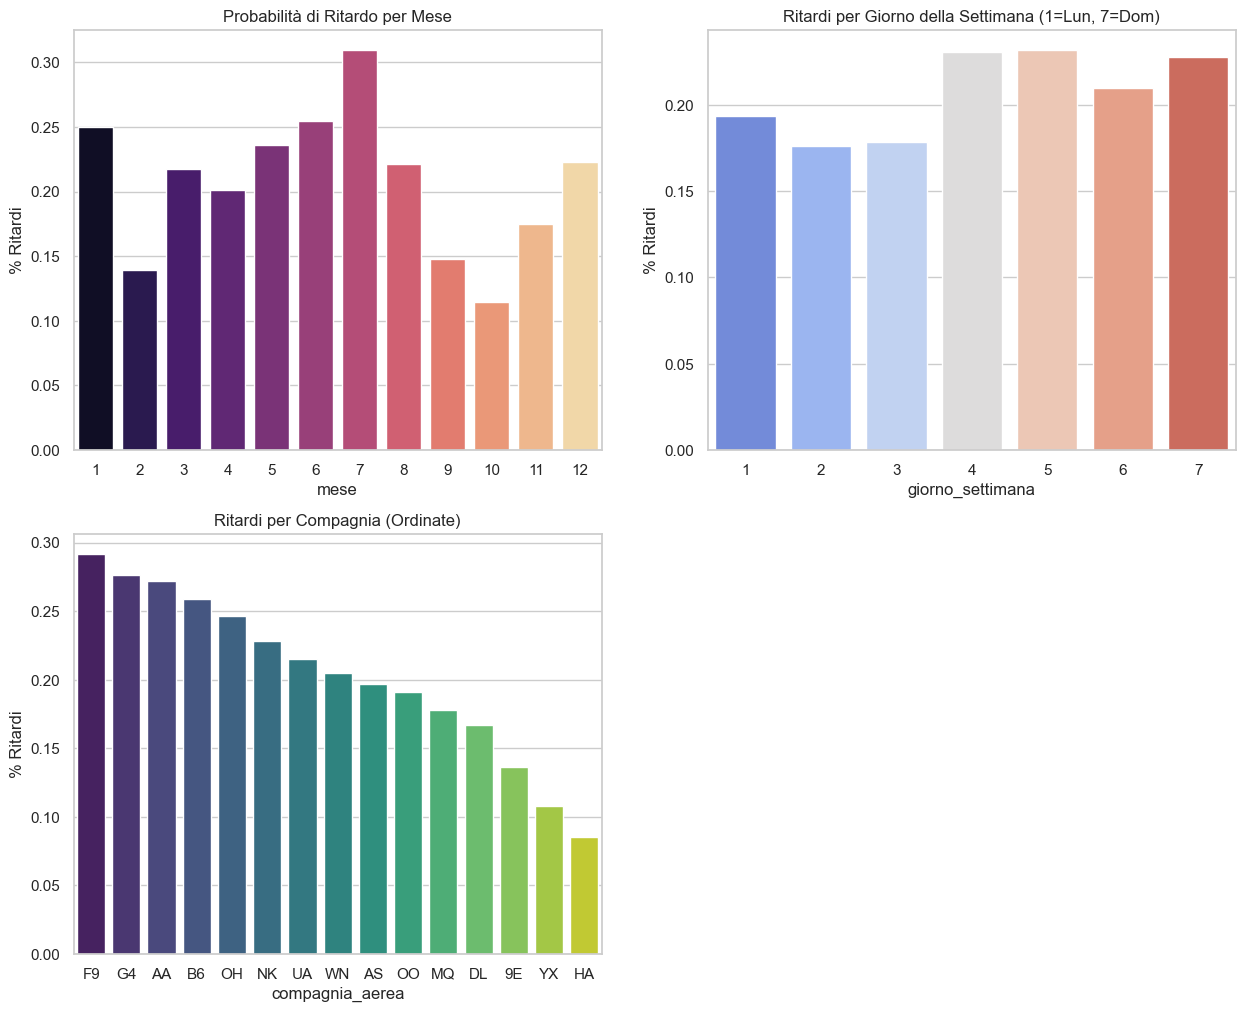

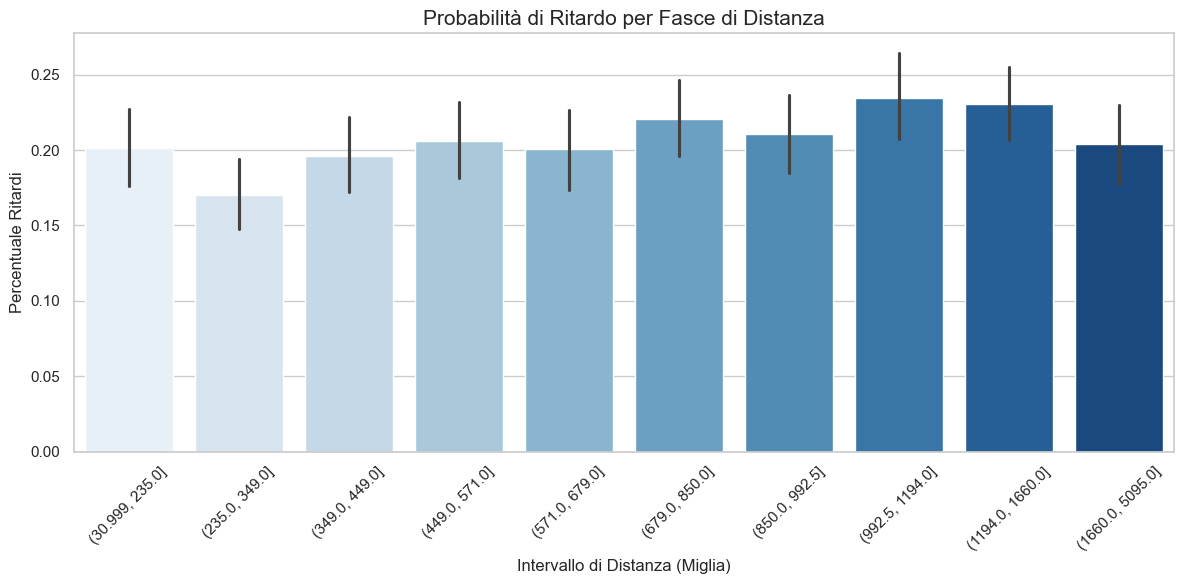

In [13]:
# Impostiamo lo stile
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# 1. In che mesi ci sono più ritardi?
plt.subplot(2, 2, 1)
sns.barplot(data=df_clean, x='mese', y='in_ritardo', errorbar=None, palette='magma')
plt.title('Probabilità di Ritardo per Mese')
plt.ylabel('% Ritardi')

# 2. In che periodo della settimana ci sono più ritardi?
plt.subplot(2, 2, 2)
sns.barplot(data=df_clean, x='giorno_settimana', y='in_ritardo', errorbar=None, palette='coolwarm')
plt.title('Ritardi per Giorno della Settimana (1=Lun, 7=Dom)')
plt.ylabel('% Ritardi')

# 3. Quale compagnia aerea ha più ritardi?
plt.subplot(2, 2, 3)
# Ordiniamo le compagnie dalla peggiore alla migliore
order = df_clean.groupby('compagnia_aerea')['in_ritardo'].mean().sort_values(ascending=False).index
sns.barplot(data=df_clean, x='compagnia_aerea', y='in_ritardo', order=order, errorbar=None, palette='viridis')
plt.title('Ritardi per Compagnia (Ordinate)')
plt.ylabel('% Ritardi')

# 1. CREIAMO LE FASCE DI DISTANZA (Binned Bar Chart)
# Dividiamo la distanza in 10 gruppi uguali (decili)
df_clean['fascia_distanza'] = pd.qcut(df_clean['distanza_miglia'], q=10)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_clean, x='fascia_distanza', y='in_ritardo', palette='Blues')
plt.xticks(rotation=45)
plt.title('Probabilità di Ritardo per Fasce di Distanza', fontsize=15)
plt.xlabel('Intervallo di Distanza (Miglia)')
plt.ylabel('Percentuale Ritardi')

plt.tight_layout()
plt.show()